In [3]:
import pandas as pd
import json

# Load normal traces (sample first)
df_normal = pd.read_csv('../data/HDFS_v3_TraceBench/preprocessed/normal_trace.csv', nrows=1000)
print("Normal trace columns:", df_normal.columns.tolist())
print("\nSample normal trace:")
print(df_normal.head())
print(f"\nShape: {df_normal.shape}")

# Load failure traces (sample)
df_failure = pd.read_csv('../data/HDFS_v3_TraceBench/preprocessed/failure_trace.csv', nrows=1000)
print("\nFailure trace columns:", df_failure.columns.tolist())
print("\nSample failure trace:")
print(df_failure.head())
print(f"\nShape: {df_failure.shape}")

# Load event mappings
with open('../data/HDFS_v3_TraceBench/preprocessed/eventId.json', 'r') as f:
    event_mapping = json.load(f)
print(f"\nNumber of unique events: {len(event_mapping)}")


Normal trace columns: ['TaskID', 'getFileInfo+success: return(ow[class=class org.apache.hadoop.hdfs.protocol.hdfsfilestatus', 'RPC:getFileInfo+success: return(ow[class=class org.apache.hadoop.hdfs.protocol.hdfsfilestatus', 'getBlockLocations+success: return(ow[class=class org.apache.hadoop.hdfs.protocol.locatedblocks', 'RPC:getBlockLocations+success: return(ow[class=class org.apache.hadoop.hdfs.protocol.locatedblocks', 'bestNode+success: chosen bestnode = in nodes = ', 'chooseDataNode+success: chosennode = /', 'OP: new blockSender+success: return(op_status_success)', 'newBlockReader+success: return a valid blockreader', 'OP: try new BlockReader+success: chosennode = ', 'blockSeekTo+success: chosennode = for blk_of /user/hadoop/hdfsfile_blocks', 'blockSeekTo+success: chosennode = for blk_-of /user/hadoop/hdfsfile_blocks', 'sendBlock+success: send blk_-', 'OP: receive block+success: received a block', 'checksumOk+success:', 'fs -copyToLocal+a user task', 'verifiedByClient+success: blk_-v

In [5]:
import pandas as pd
import numpy as np

# Load normal traces (will take 2-3 minutes for 1.96 GB)
print("Loading normal traces...")
df_normal = pd.read_csv('../data/HDFS_v3_TraceBench/preprocessed/normal_trace.csv')
print(f"Normal traces loaded: {df_normal.shape}")

# Load failure traces
print("Loading failure traces...")
df_failure = pd.read_csv('../data/HDFS_v3_TraceBench/preprocessed/failure_trace.csv')
print(f"Failure traces loaded: {df_failure.shape}")

# Add labels
df_normal['Label'] = 0  # Normal
df_failure['Label'] = 1  # Anomaly

# Combine datasets
df_full = pd.concat([df_normal, df_failure], ignore_index=True)

# Save TaskIDs separately
task_ids = df_full['TaskID'].copy()

# Drop TaskID column for modeling
X_df = df_full.drop(['TaskID', 'Label'], axis=1)
y = df_full['Label'].values

print(f"\nFinal dataset shape:")
print(f"X shape: {X_df.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {X_df.shape[1]}")
print(f"Normal traces: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"Anomaly traces: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")

# Convert to numpy arrays
X = X_df.values

# Save processed data
np.save('../data/X_tracebench.npy', X)
np.save('../data/y_tracebench.npy', y)
task_ids.to_csv('../data/task_ids.csv', index=False)


Loading normal traces...
Normal traces loaded: (226767, 2156)
Loading failure traces...
Failure traces loaded: (29817, 2156)

Final dataset shape:
X shape: (256584, 2155)
y shape: (256584,)
Features: 2155
Normal traces: 226767 (88.4%)
Anomaly traces: 29817 (11.6%)


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load normal traces with pandas (handles special characters)
print("Loading normal traces...")
df_normal = pd.read_csv('../data/HDFS_v3_TraceBench/preprocessed/normal_trace.csv')
df_normal['Label'] = 0
print(f"Normal traces: {df_normal.shape}")

# Load failure traces
print("Loading failure traces...")
df_failure = pd.read_csv('../data/HDFS_v3_TraceBench/preprocessed/failure_trace.csv')
df_failure['Label'] = 1
print(f"Failure traces: {df_failure.shape}")

# Combine
df_full = pd.concat([df_normal, df_failure], ignore_index=True)
print(f"Combined: {df_full.shape}")

# Separate TaskID and features
task_ids = df_full['TaskID'].copy()
X_df = df_full.drop(['TaskID', 'Label'], axis=1)
y = df_full['Label'].values

print(f"\nFeatures: {X_df.shape[1]}")
print(f"Normal: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"Anomaly: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")

# Scale features
print("\nScaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df.values)

# Save processed data
np.save('../data/X_scaled.npy', X_scaled)
np.save('../data/y.npy', y)
task_ids.to_csv('../data/task_ids.csv', index=False)

print(f"Saved scaled data: {X_scaled.shape}")


Loading normal traces...
Normal traces: (226767, 2157)
Loading failure traces...
Failure traces: (29817, 2157)
Combined: (256584, 2157)

Features: 2155
Normal: 226767 (88.4%)
Anomaly: 29817 (11.6%)

Scaling features...
Saved scaled data: (256584, 2155)


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Load your saved data
X_scaled = np.load('../data/X_scaled.npy')
y = np.load('../data/y.npy')

print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print(f"Normal: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"Anomaly: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")

# Split data (70% train, 15% validation, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y  # Maintain class distribution
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train anomalies: {(y_train==1).sum()}/{len(y_train)} ({(y_train==1).mean()*100:.1f}%)")
print(f"Val anomalies: {(y_val==1).sum()}/{len(y_val)} ({(y_val==1).mean()*100:.1f}%)")
print(f"Test anomalies: {(y_test==1).sum()}/{len(y_test)} ({(y_test==1).mean()*100:.1f}%)")

# Compute class weights to handle imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\nClass weights: {class_weight_dict}")
# Expected: Normal ~0.57, Anomaly ~4.32


X shape: (256584, 2155)
y shape: (256584,)
Normal: 226767 (88.4%)
Anomaly: 29817 (11.6%)

Train: (179608, 2155), Val: (38488, 2155), Test: (38488, 2155)
Train anomalies: 20872/179608 (11.6%)
Val anomalies: 4473/38488 (11.6%)
Test anomalies: 4472/38488 (11.6%)

Class weights: {0: np.float64(0.5657443806067937), 1: np.float64(4.302606362591031)}


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Build Deep Neural Network
input_dim = X_train.shape[1]  # 2155 features

model = Sequential([
    # Input layer + First hidden layer
    Dense(512, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.4),
    
    # Second hidden layer
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # Third hidden layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # Fourth hidden layer
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    # Fifth hidden layer
    Dense(32, activation='relu'),
    
    # Output layer (binary classification)
    Dense(1, activation='sigmoid')
], name='HDFS_Anomaly_Detection_DNN')

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(name='auc_pr', curve='PR')  # Precision-Recall AUC
    ]
)

# Print model summary
model.summary()

# Save model architecture
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='../results/model_architecture.png', 
           show_shapes=True, show_layer_names=True, dpi=150)
print("\nModel architecture saved to results/model_architecture.png")


c:\Users\home\anaconda3\envs\project1\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "HDFS_Anomaly_Detection_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,103,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282,049 (4.89 MB)

 Trainable params: 1,280,257 (4.88 MB)

 Non-trainable params: 1,792 (7.00 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.

Model architecture saved to results/model_architecture.png


In [6]:
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ModelCheckpoint, 
    ReduceLROnPlateau,
    TensorBoard
)
import datetime

# Create callbacks
callbacks = [
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_auc',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    
    # Save best model
    ModelCheckpoint(
        '../models/best_hdfs_model.h5',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    # Reduce learning rate when plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),
    
    # TensorBoard logging
    TensorBoard(
        log_dir=f'../logs/{datetime.datetime.now().strftime("%Y%m%d-%H%M%S")}',
        histogram_freq=1
    )
]

# Train model
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,  # Will stop early if no improvement
    batch_size=128,
    class_weight=class_weight_dict,  # Handle imbalance
    callbacks=callbacks,
    verbose=1
)

# Save final model
model.save('../models/hdfs_anomaly_final.h5')
print("\nModel saved to models/hdfs_anomaly_final.h5")

# Save training history
import pandas as pd
history_df = pd.DataFrame(history.history)
history_df.to_csv('../results/training_history.csv', index=False)
print("Training history saved to results/training_history.csv")



STARTING TRAINING
Epoch 1/10
1396/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9988 - auc: 0.9998 - auc_pr: 0.9983 - loss: 0.0040 - precision: 0.9908 - recall: 0.9990
Epoch 1: val_auc improved from -inf to 0.99951, saving model to ../models/best_hdfs_model.h5


1404/1404 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9988 - auc: 0.9998 - auc_pr: 0.9983 - loss: 0.0040 - precision: 0.9908 - recall: 0.9990 - val_accuracy: 0.9997 - val_auc: 0.9995 - val_auc_pr: 0.9987 - val_loss: 0.0019 - val_precision: 0.9989 - val_recall: 0.9989 - learning_rate: 5.0000e-04
Epoch 2/10
1396/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9997 - auc: 1.0000 - auc_pr: 0.9994 - loss: 0.0010 - precision: 0.9973 - recall: 0.9998
Epoch 2: val_auc improved from 0.99951 to 0.99963, saving model to ../models/best_hdfs_model.h5


1404/1404 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9997 - auc: 1.0000 - auc_pr: 0.9994 - loss: 0.0010 - precision: 0.9974 - recall: 0.9998 - val_accuracy: 0.9997 - val_auc: 0.9996 - val_auc_pr: 0.9990 - val_loss: 0.0019 - val_precision: 0.9991 - val_recall: 0.9987 - learning_rate: 5.0000e-04
Epoch 3/10
1395/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9998 - auc: 1.0000 - auc_pr: 0.9995 - loss: 7.5095e-04 - precision: 0.9985 - recall: 1.0000
Epoch 3: val_auc improved from 0.99963 to 0.99998, saving model to ../models/best_hdfs_model.h5


1404/1404 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9998 - auc: 1.0000 - auc_pr: 0.9995 - loss: 7.5447e-04 - precision: 0.9985 - recall: 1.0000 - val_accuracy: 0.9998 - val_auc: 1.0000 - val_auc_pr: 0.9997 - val_loss: 8.8365e-04 - val_precision: 0.9989 - val_recall: 0.9998 - learning_rate: 5.0000e-04
Epoch 4/10
1397/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9998 - auc: 1.0000 - auc_pr: 0.9995 - loss: 9.8905e-04 - precision: 0.9984 - recall: 0.9998
Epoch 4: val_auc did not improve from 0.99998
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9998 - auc: 1.0000 - auc_pr: 0.9995 - loss: 9.8959e-04 - precision: 0.9984 - recall: 0.9998 - val_accuracy: 0.9995 - val_auc: 0.9981 - val_auc_pr: 0.9966 - val_loss: 0.0103 - val_precision: 0.9991 - val_recall: 0.9962 - learning_rate: 5.0000e-04
Epoch 5/10
1402/1404 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9998 - auc: 1.0000 - auc_pr: 0.9995 - loss: 7.1971e-04 - precision: 0.9985 - recall: 0.9999
Epoch 5: val_auc did not


Model saved to models/hdfs_anomaly_final.h5
Training history saved to results/training_history.csv


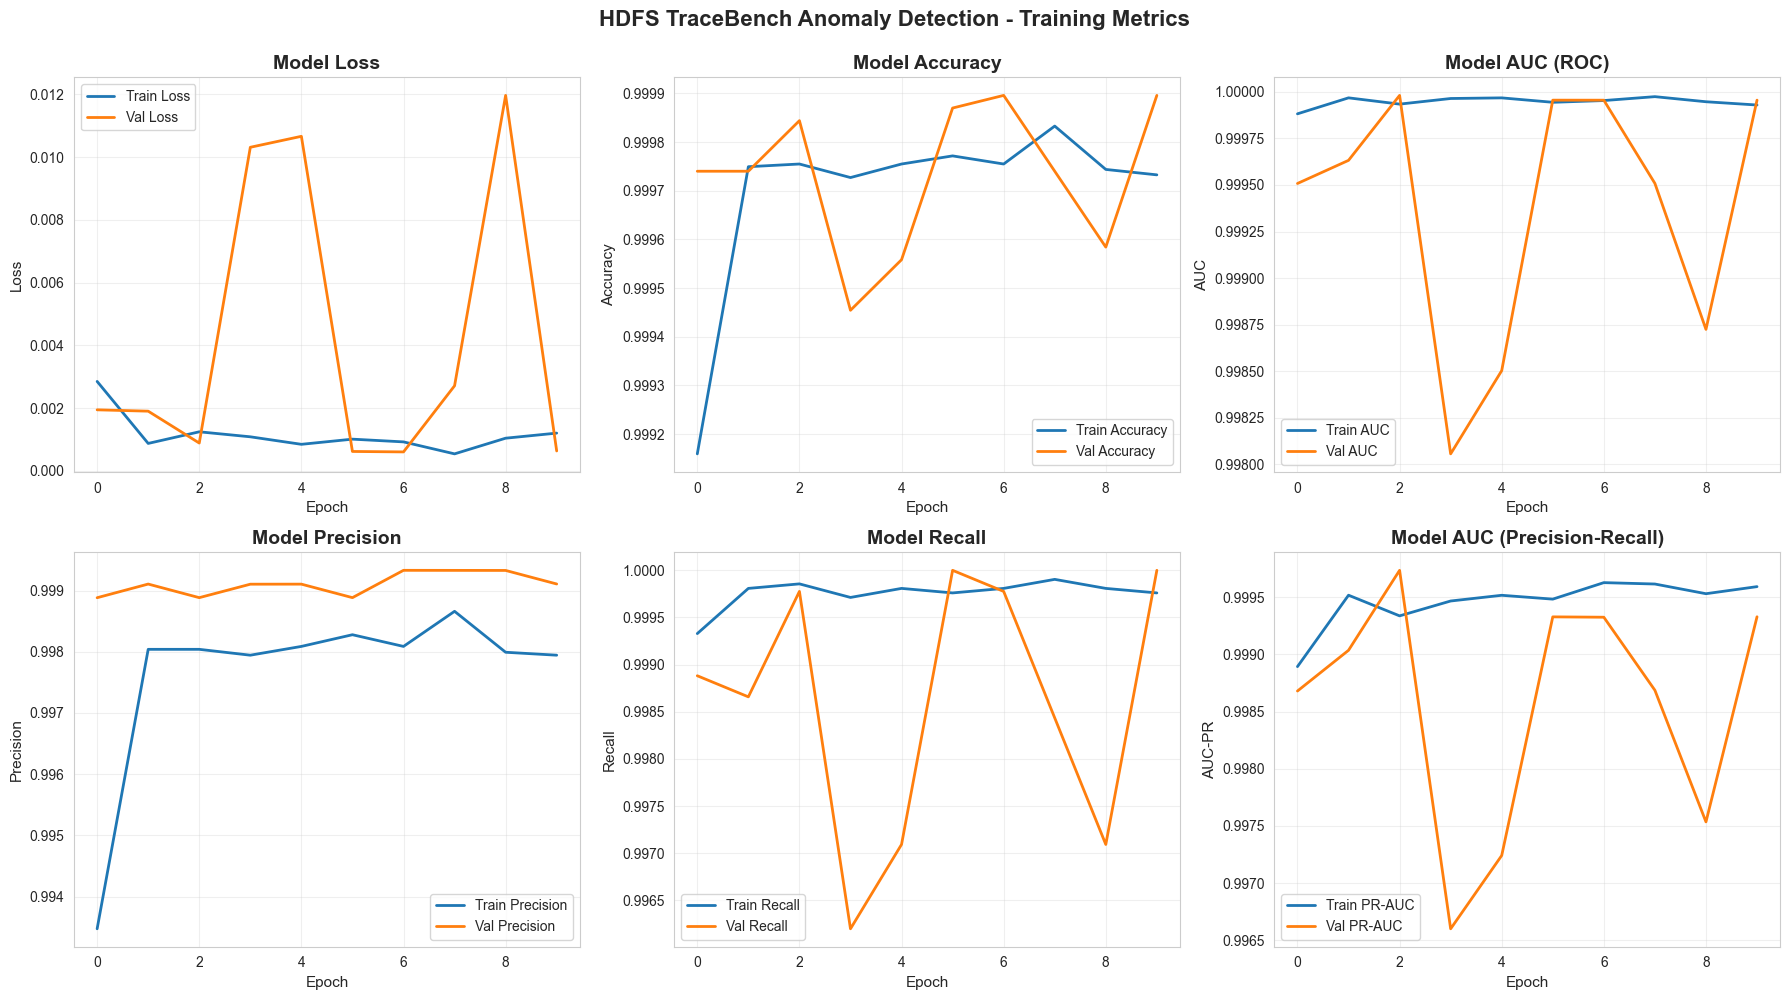

Training metrics visualization saved!


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Accuracy', fontsize=11)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. AUC
axes[0, 2].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[0, 2].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[0, 2].set_title('Model AUC (ROC)', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch', fontsize=11)
axes[0, 2].set_ylabel('AUC', fontsize=11)
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# 4. Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Precision', fontsize=11)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 5. Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Recall', fontsize=11)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# 6. PR-AUC
axes[1, 2].plot(history.history['auc_pr'], label='Train PR-AUC', linewidth=2)
axes[1, 2].plot(history.history['val_auc_pr'], label='Val PR-AUC', linewidth=2)
axes[1, 2].set_title('Model AUC (Precision-Recall)', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Epoch', fontsize=11)
axes[1, 2].set_ylabel('AUC-PR', fontsize=11)
axes[1, 2].legend(fontsize=10)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('HDFS TraceBench Anomaly Detection - Training Metrics', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training metrics visualization saved!")


In [9]:
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Load best model
best_model = tf.keras.models.load_model('../models/best_hdfs_model.h5')

# Predict on test set
print("Predicting on test set...")
y_pred_prob = best_model.predict(X_test, verbose=1).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT - TEST SET")
print("="*70)
print(classification_report(
    y_test, y_pred, 
    target_names=['Normal', 'Anomaly'],
    digits=4
))

# Calculate metrics
accuracy = (y_pred == y_test).mean()
roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
print(f"\nSpecificity (True Negative Rate): {specificity:.4f}")
print(f"Sensitivity (True Positive Rate): {sensitivity:.4f}")

# Save predictions
predictions_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred,
    'Anomaly_Probability': y_pred_prob,
    'Correct': y_pred == y_test
})
predictions_df.to_csv('../results/test_predictions.csv', index=False)
print("\nPredictions saved to results/test_predictions.csv")


Predicting on test set...
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step

CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000     34016
     Anomaly     0.9998    0.9998    0.9998      4472

    accuracy                         0.9999     38488
   macro avg     0.9999    0.9999    0.9999     38488
weighted avg     0.9999    0.9999    0.9999     38488


Accuracy: 0.9999
ROC-AUC: 1.0000
PR-AUC: 0.9998

Confusion Matrix:
[[34015     1]
 [    1  4471]]

Specificity (True Negative Rate): 1.0000
Sensitivity (True Positive Rate): 0.9998

Predictions saved to results/test_predictions.csv


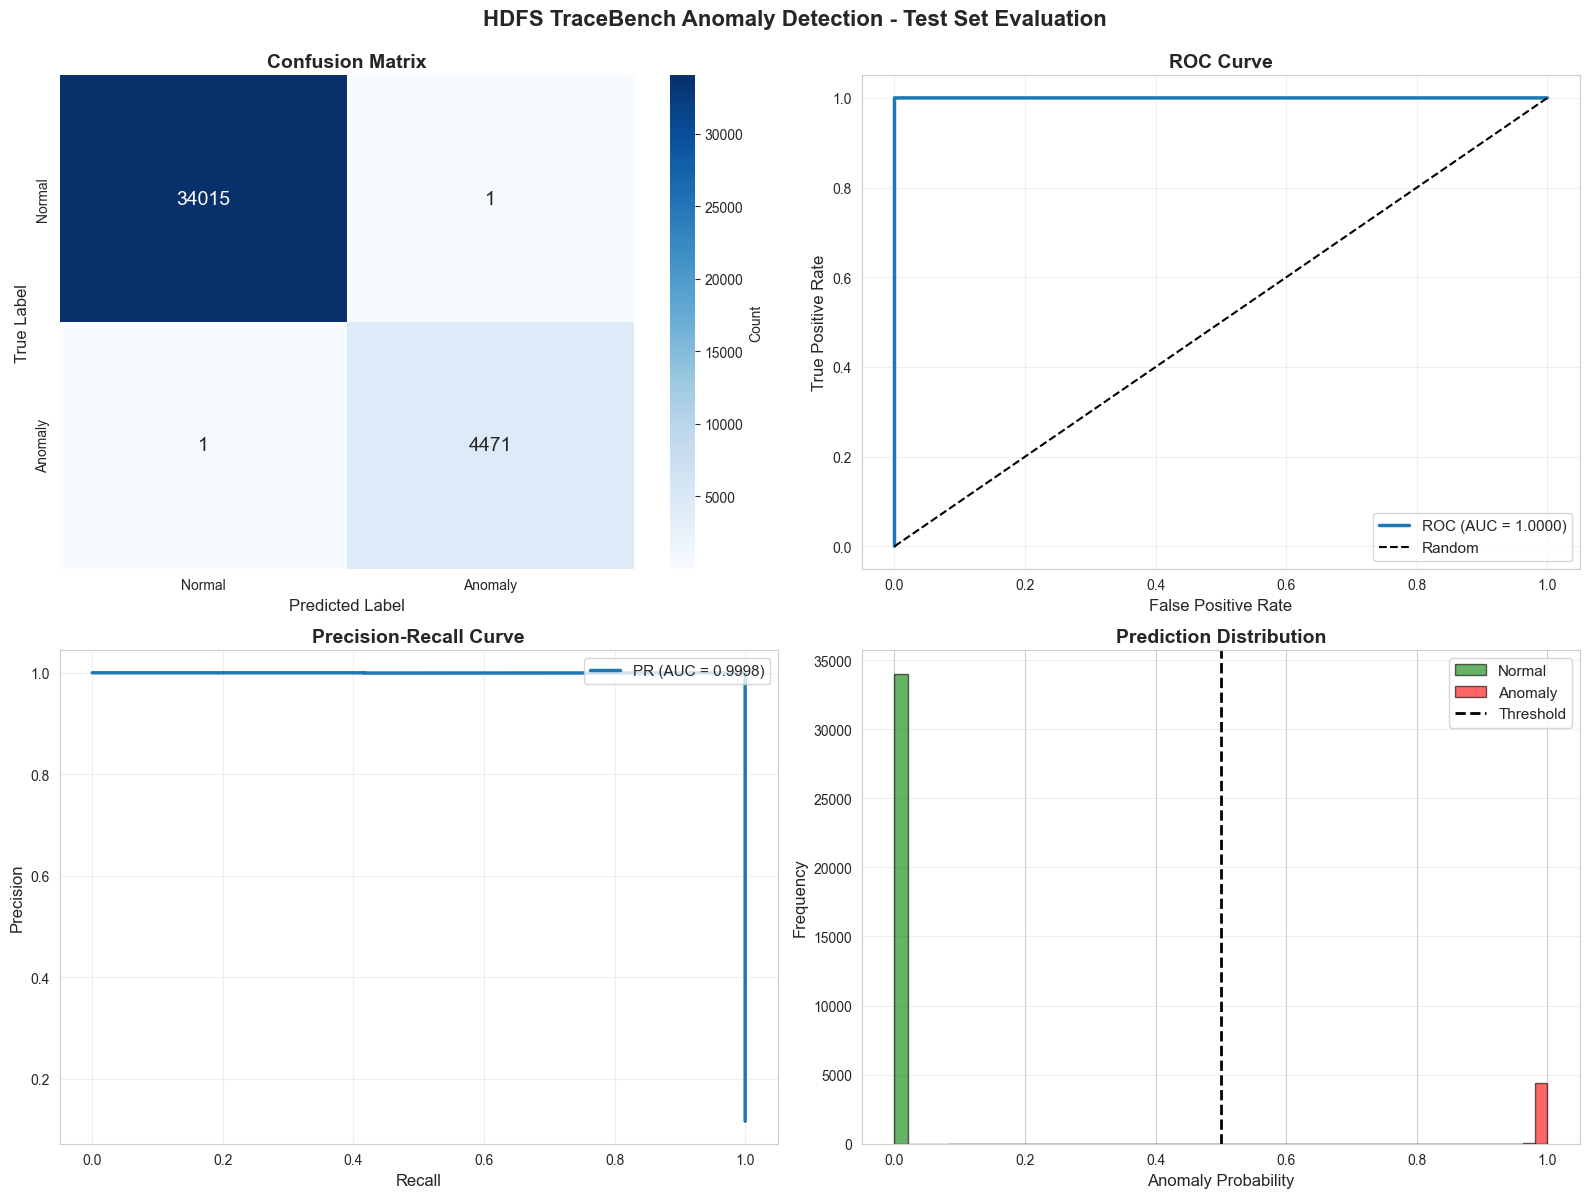

Test evaluation plots saved!


In [10]:
# Create comprehensive evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'},
            ax=axes[0, 0],
            annot_kws={'size': 14})
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('True Label', fontsize=12)
axes[0, 0].set_xlabel('Predicted Label', fontsize=12)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[0, 1].plot(fpr, tpr, linewidth=2.5, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='lower right', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
axes[1, 0].plot(recall, precision, linewidth=2.5, label=f'PR (AUC = {pr_auc:.4f})')
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc='upper right', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 4. Prediction Distribution
axes[1, 1].hist(y_pred_prob[y_test==0], bins=50, alpha=0.6, 
                label='Normal', color='green', edgecolor='black')
axes[1, 1].hist(y_pred_prob[y_test==1], bins=50, alpha=0.6, 
                label='Anomaly', color='red', edgecolor='black')
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1, 1].set_xlabel('Anomaly Probability', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Prediction Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('HDFS TraceBench Anomaly Detection - Test Set Evaluation', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/test_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Test evaluation plots saved!")


In [11]:
import time
from IPython.display import clear_output

def simulate_real_time_detection(model, X_test, y_test, num_samples=100):
    """
    Simulate real-time anomaly detection for demo
    """
    print("="*70)
    print("REAL-TIME HDFS ANOMALY DETECTION SIMULATION")
    print("="*70)
    
    results = []
    
    for i in range(num_samples):
        # Get sample
        sample = X_test[i:i+1]
        true_label = y_test[i]
        
        # Predict
        pred_prob = model.predict(sample, verbose=0)[0][0]
        pred_label = 1 if pred_prob > 0.5 else 0
        
        # Store result
        results.append({
            'trace_id': i,
            'true_label': 'Anomaly' if true_label == 1 else 'Normal',
            'pred_label': 'Anomaly' if pred_label == 1 else 'Normal',
            'confidence': pred_prob if pred_label == 1 else 1 - pred_prob,
            'correct': pred_label == true_label
        })
        
        # Print status every 10 traces
        if (i + 1) % 10 == 0:
            accuracy = sum([r['correct'] for r in results]) / len(results)
            print(f"Processed {i+1}/{num_samples} traces | Accuracy: {accuracy:.2%}")
        
        # Simulate streaming delay
        time.sleep(0.05)
    
    results_df = pd.DataFrame(results)
    
    # Summary
    print("\n" + "="*70)
    print("DETECTION SUMMARY")
    print("="*70)
    print(f"Total traces analyzed: {len(results)}")
    print(f"Anomalies detected: {sum([1 for r in results if r['pred_label']=='Anomaly'])}")
    print(f"Normal traces: {sum([1 for r in results if r['pred_label']=='Normal'])}")
    print(f"Accuracy: {results_df['correct'].mean():.2%}")
    
    return results_df

# Run simulation
demo_results = simulate_real_time_detection(best_model, X_test, y_test, num_samples=100)

# Save demo results
demo_results.to_csv('../results/demo_results.csv', index=False)


REAL-TIME HDFS ANOMALY DETECTION SIMULATION
Processed 10/100 traces | Accuracy: 100.00%
Processed 20/100 traces | Accuracy: 100.00%
Processed 30/100 traces | Accuracy: 100.00%
Processed 40/100 traces | Accuracy: 100.00%
Processed 50/100 traces | Accuracy: 100.00%
Processed 60/100 traces | Accuracy: 100.00%
Processed 70/100 traces | Accuracy: 100.00%
Processed 80/100 traces | Accuracy: 100.00%
Processed 90/100 traces | Accuracy: 100.00%
Processed 100/100 traces | Accuracy: 100.00%

DETECTION SUMMARY
Total traces analyzed: 100
Anomalies detected: 12
Normal traces: 88
Accuracy: 100.00%


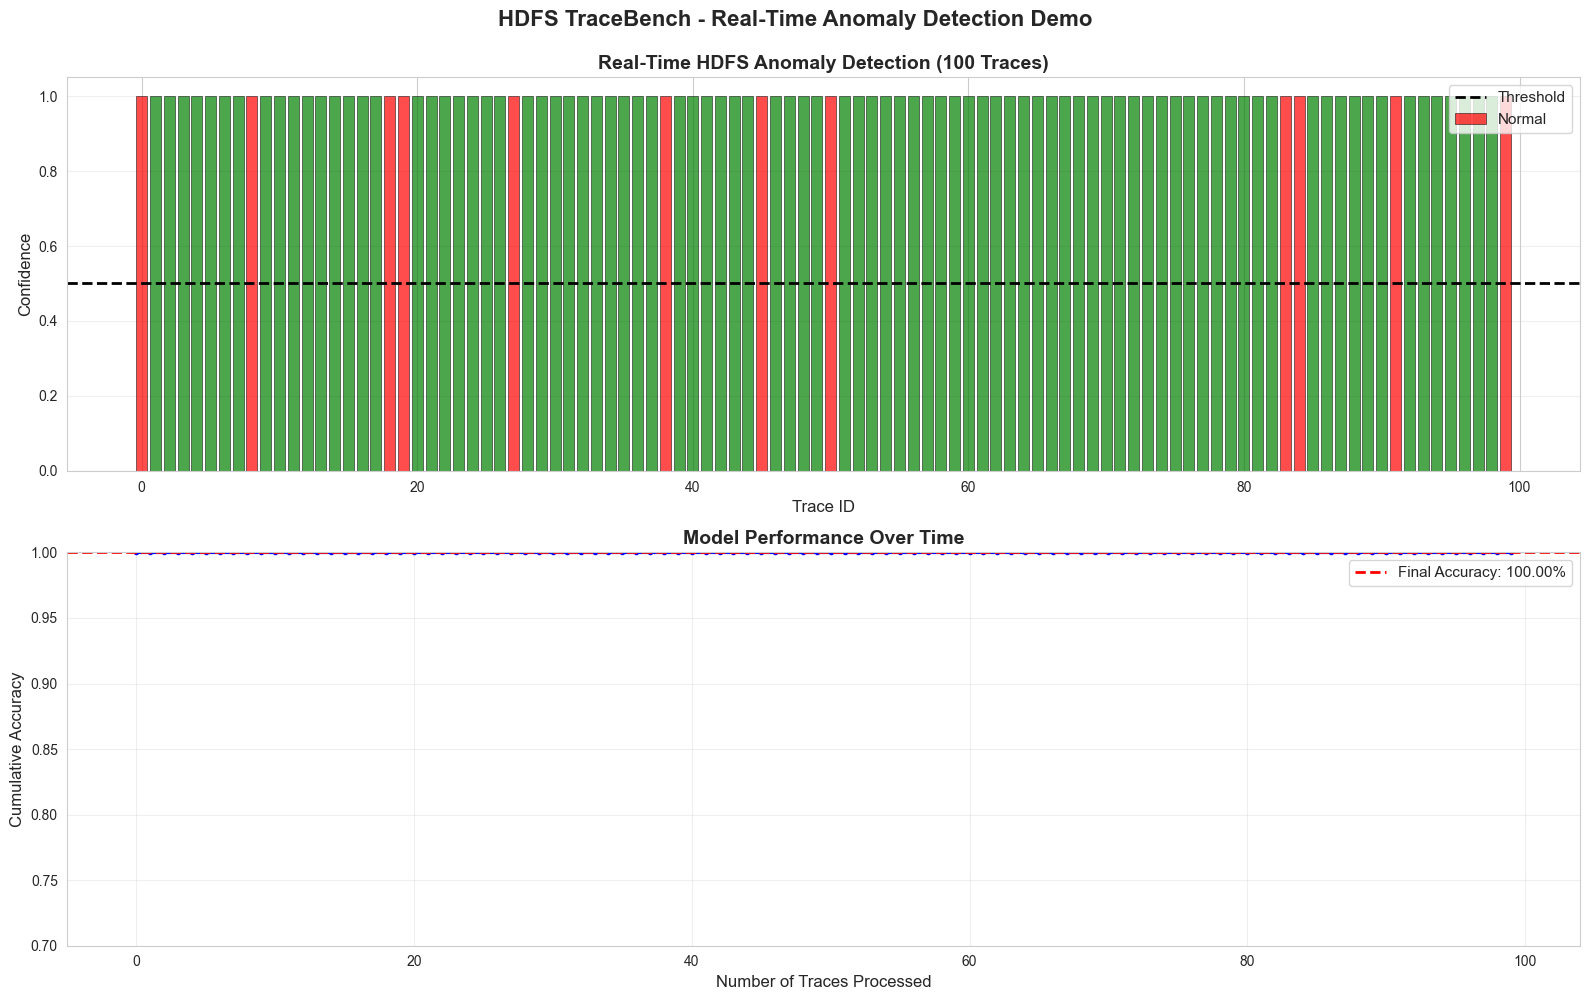

Demo visualization saved!


In [12]:
# Create demo visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Real-time detection bar chart
colors = ['red' if label == 'Anomaly' else 'green' for label in demo_results['pred_label']]
axes[0].bar(demo_results['trace_id'], demo_results['confidence'], 
            color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_xlabel('Trace ID', fontsize=12)
axes[0].set_ylabel('Confidence', fontsize=12)
axes[0].set_title('Real-Time HDFS Anomaly Detection (100 Traces)', 
                  fontsize=14, fontweight='bold')
axes[0].legend(['Threshold', 'Normal', 'Anomaly'], fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Cumulative accuracy
cumulative_accuracy = []
for i in range(len(demo_results)):
    acc = demo_results['correct'][:i+1].mean()
    cumulative_accuracy.append(acc)

axes[1].plot(demo_results['trace_id'], cumulative_accuracy, 
             linewidth=3, color='blue', marker='o', markersize=3)
axes[1].axhline(y=cumulative_accuracy[-1], color='red', 
                linestyle='--', linewidth=2, 
                label=f'Final Accuracy: {cumulative_accuracy[-1]:.2%}')
axes[1].set_xlabel('Number of Traces Processed', fontsize=12)
axes[1].set_ylabel('Cumulative Accuracy', fontsize=12)
axes[1].set_title('Model Performance Over Time', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.7, 1.0])

plt.suptitle('HDFS TraceBench - Real-Time Anomaly Detection Demo', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/demo_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Demo visualization saved!")
